In [7]:
import os
import json
import numpy as np
import torch
import torch.nn as nn

# Define LSTM model
class LSTMGestureModel(nn.Module):
    def __init__(self, input_dim=63, hidden_dim=256, output_dim=128, num_layers=2):
        super(LSTMGestureModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x, _ = self.lstm(x)
        return self.fc(x[:, -1, :])  # Take last time step output

# Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMGestureModel().to(device)
model.load_state_dict(torch.load("model_epoch_146.pth", map_location=device))
model.eval()  # Set model to evaluation mode
print("Model loaded successfully.")

# Path to dataset
data_path = "augmented_train_data_concatenated_delta_landmark0"

# Dictionary to store class means
class_means = {}

# Process each class
for class_name in sorted(os.listdir(data_path)):
    class_path = os.path.join(data_path, class_name)
    
    if os.path.isdir(class_path):
        embeddings = []
        
        for file in os.listdir(class_path):
            if file.endswith('.csv'):
                file_path = os.path.join(class_path, file)
                sequence = np.loadtxt(file_path, delimiter=',', dtype=np.float32)

                # Convert to PyTorch tensor and move to device
                sequence = torch.tensor(sequence, dtype=torch.float32, device=device).unsqueeze(0)  # Add batch dim (1, frame_len, 60)

                # Get the embedding (128-dimensional vector)
                with torch.no_grad():
                    embedding = model(sequence).cpu().numpy().squeeze()  # Move to CPU and remove batch dim
                embeddings.append(embedding)
        
        # Compute mean embedding for this class
        if embeddings:
            class_mean = np.mean(embeddings, axis=0)
            class_means[class_name] = class_mean.tolist()  # Convert to list for JSON serialization

# Save to JSON file
with open("class_means_lstm.json", "w") as f:
    json.dump(class_means, f, indent=4)

print("Class means computed and saved to 'class_means_lstm.json'.")



# Compute how many sequences are within 0.5 distance from class mean
print("\nChecking distance from class mean:")
for class_name in sorted(os.listdir(data_path)):
    class_path = os.path.join(data_path, class_name)

    if os.path.isdir(class_path):
        class_mean = np.array(class_means[class_name])  # Load class mean
        total_samples = 0
        within_threshold = 0

        for file in os.listdir(class_path):
            if file.endswith('.csv'):
                file_path = os.path.join(class_path, file)
                sequence = np.loadtxt(file_path, delimiter=',', dtype=np.float32)

                # Convert to PyTorch tensor
                sequence = torch.tensor(sequence, dtype=torch.float32, device=device).unsqueeze(0)

                # Get the embedding
                with torch.no_grad():
                    embedding = model(sequence).cpu().numpy().squeeze()

                # Compute distance from class mean
                distance = np.linalg.norm(embedding - class_mean)
                if distance < 0.5:
                    within_threshold += 1
                total_samples += 1

        print(f"Class {class_name}: {within_threshold}/{total_samples} sequences within 0.5 distance from class mean")


Model loaded successfully.
Class means computed and saved to 'class_means_lstm.json'.

Checking distance from class mean:
Class B0A: 120/121 sequences within 0.5 distance from class mean
Class B0B: 120/123 sequences within 0.5 distance from class mean
Class G01: 12/120 sequences within 0.5 distance from class mean
Class G02: 0/120 sequences within 0.5 distance from class mean
Class G03: 16/120 sequences within 0.5 distance from class mean
Class G04: 0/120 sequences within 0.5 distance from class mean
Class G05: 0/120 sequences within 0.5 distance from class mean
Class G06: 50/120 sequences within 0.5 distance from class mean
Class G07: 17/120 sequences within 0.5 distance from class mean
Class G08: 79/120 sequences within 0.5 distance from class mean
Class G09: 2/120 sequences within 0.5 distance from class mean
Class G10: 0/120 sequences within 0.5 distance from class mean
Class G11: 22/120 sequences within 0.5 distance from class mean


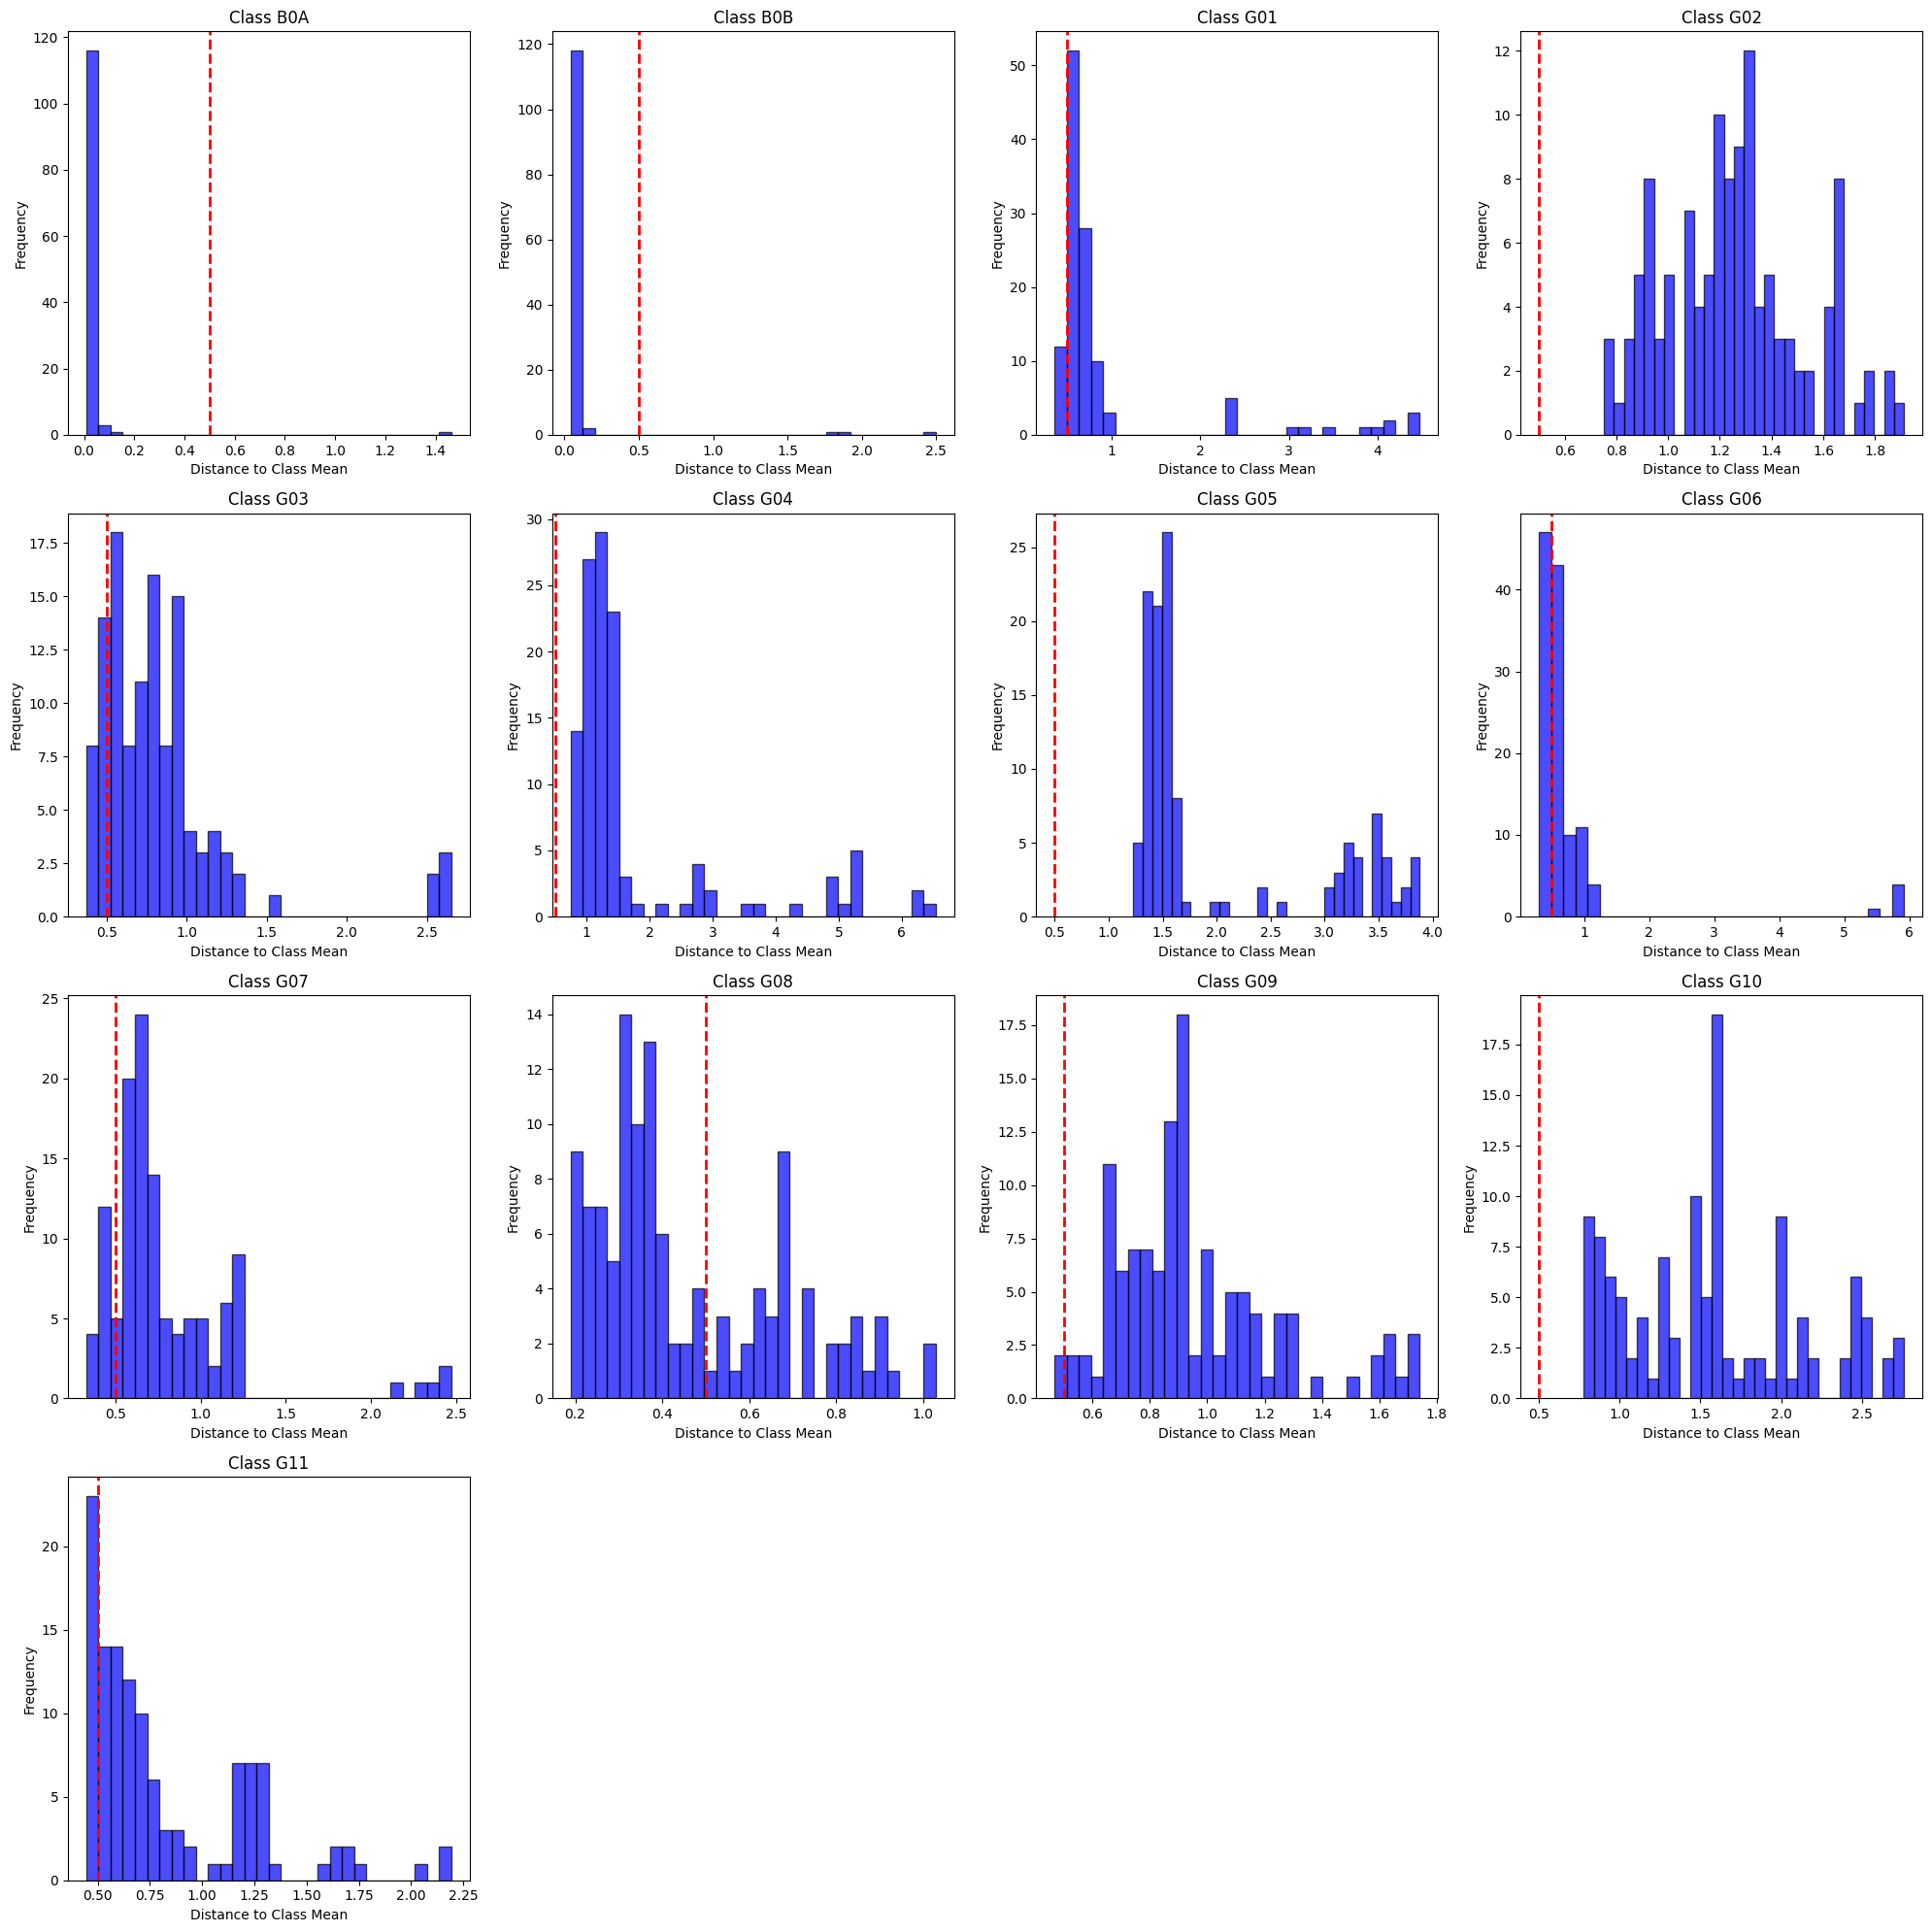

In [8]:
import matplotlib.pyplot as plt


# Load class means
with open("class_means_lstm.json", "r") as f:
    class_means = json.load(f)

# Path to dataset
# data_path = "augmented_latent_space_train_data_concatenated_delta_landmark0"

# Dictionary to store distances for each class
class_distances = {}

# Process each class
for class_name in sorted(os.listdir(data_path)):
    class_path = os.path.join(data_path, class_name)
    
    if os.path.isdir(class_path):
        distances = []

        for file in os.listdir(class_path):
            if file.endswith('.csv'):
                file_path = os.path.join(class_path, file)
                sequence = np.loadtxt(file_path, delimiter=',', dtype=np.float32)

                # Convert to Tensor and add batch dimension
                sequence = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, frame_len, 131)

                # Pass through model to get embedding
                with torch.no_grad():
                    embedding = model(sequence).cpu().numpy()[0]  # Shape: (128,)

                # Compute distance from class mean
                class_mean = np.array(class_means[class_name])
                distance = np.linalg.norm(embedding - class_mean)
                distances.append(distance)

        # Store distances
        class_distances[class_name] = distances

# Plot subplots for each class
num_classes = len(class_distances)
cols = 4  # Number of columns in the subplot grid
rows = (num_classes // cols) + (num_classes % cols > 0)  # Compute number of rows

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()  # Flatten to easily iterate

for i, (class_name, distances) in enumerate(class_distances.items()):
    ax = axes[i]
    ax.hist(distances, bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax.axvline(x=0.5, color='r', linestyle='dashed', linewidth=2)  # Threshold line
    ax.set_title(f"Class {class_name}")
    ax.set_xlabel("Distance to Class Mean")
    ax.set_ylabel("Frequency")

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

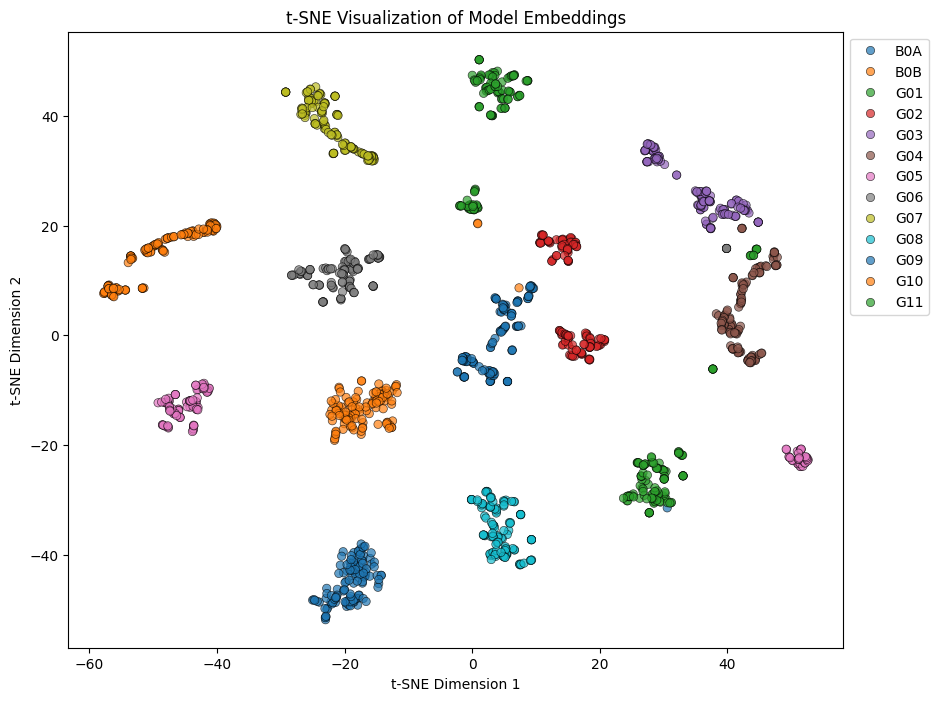

In [9]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Collect embeddings and labels
embeddings = []
labels = []

for class_name in sorted(os.listdir(data_path)):
    class_path = os.path.join(data_path, class_name)
    
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.endswith('.csv'):
                file_path = os.path.join(class_path, file)
                sequence = np.loadtxt(file_path, delimiter=',', dtype=np.float32)

                # Convert to Tensor and add batch dimension
                sequence = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)

                # Pass through model to get embedding
                with torch.no_grad():
                    embedding = model(sequence).cpu().numpy().flatten()  # Ensures it's a 1D array
                
                embeddings.append(embedding)
                labels.append(class_name)

# Convert to numpy arrays
embeddings = np.vstack(embeddings)  # Use vstack to ensure correct shape
labels = np.array(labels)

# Apply t-SNE with adjusted parameters
tsne = TSNE(n_components=2, perplexity=min(30, len(embeddings) - 1), init='pca', random_state=42)
embedded_points = tsne.fit_transform(embeddings)

# Plot the results
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedded_points[:, 0], y=embedded_points[:, 1], hue=labels, palette='tab10', alpha=0.7, edgecolor='k')
plt.title("t-SNE Visualization of Model Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.show()